In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
sns.set_style("ticks")

In [2]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/dyngen.pkl' # remember to change this
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)
cluster_edges

[('sA->sB', 'sB->sBmid'),
 ('sB->sBmid', 'sBmid->sD'),
 ('sB->sBmid', 'sBmid->sC'),
 ('sBmid->sD', 'sD->sEndD'),
 ('sBmid->sC', 'sC->sEndC')]

In [3]:
import pickle as pkl

clusters_path = '../clusters/dyngen.pkl' # remember to change this
with open(clusters_path, 'rb') as f:
    clusters = pkl.load(f)
clusters

['sA->sB', 'sB->sBmid', 'sBmid->sC', 'sBmid->sD', 'sC->sEndC', 'sD->sEndD']

In [1]:
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'

In [ ]:
data = 'dyngen/standard-dataset_modified'
basis = 'umap'
metric_name = 'cbdir'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt', 'velovgi', 'latentvelo']
results = {}
for cluster_edge in cluster_edges: 
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity_{basis}.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        if edge in metric.keys():
            result[model] = metric[edge]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj_{basis}.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            if edge in stt_metric.keys():
                result['stt_vj'] = stt_metric[edge]
        if model == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity_{basis}.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            if edge in ltv_metric.keys():
                result['latentvelo_lt'] = ltv_metric[edge]
    results[edge] = result
results

In [4]:
data = 'dyngen/standard-dataset_modified'
metric_name = 'inner_cluster_coh'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt', 'velovgi', 'latentvelo']
results = {}
for cluster in clusters:
    result = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        result[model] = metric[cluster]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            result['stt_vj'] = stt_metric[cluster]
        if model == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            result['latentvelo_lt'] = ltv_metric[cluster]
    results[cluster] = result
results

{'sA->sB': {'scvelo': [0.9652807929110255,
   0.953616807191519,
   0.9436641862075624,
   0.7389851003650916,
   0.9370724335394381,
   0.9633707818178843,
   0.9490021432200405,
   0.8840730665433243,
   0.9095843417614742,
   0.9115495707487111,
   0.9024610298641934,
   0.9515508235811913,
   0.905627832716975,
   0.9187263187905348,
   0.9223826440959774,
   0.924795049449826,
   0.6877825202102149,
   0.9558884086712489,
   0.9312248337753828,
   0.939039200850118,
   0.84956392280329,
   0.8971003863314826,
   0.949376588549491,
   0.9464930003606108,
   0.9433530000524833,
   0.9277106803172847,
   0.9483475504916904,
   0.9677476728552646,
   0.9070824112671148,
   0.9614791874579955,
   0.8117965882232591,
   0.9265169648185323,
   0.9312036102521659,
   0.9454418605661492,
   0.939036479905906,
   0.9186469993023558,
   0.9488852310872355,
   0.9630472376288722,
   0.9456211734206542,
   0.8932872874157891,
   0.9232733714430224,
   0.9556549979566514,
   0.9075925513987481,

In [30]:
import pickle as pkl

data = 'hsc_revised'
basis = 'umap_ori'
metric_name = 'velocity_consistency'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt']
result = {}
for model in models:
    model_name = model if model != 'scvelo' else 'scvelo_dynamical'
    # metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_{model_name}_velocity.pkl'
    metric_file = f'../logs/{model}/real/{data}/{metric_name}_{basis}_{model_name}_velocity.pkl'
    with open(metric_file, 'rb') as f:
        metric = pkl.load(f)
    result[model] = metric
    if model == 'stt':
        # stt_metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_vj.pkl'
        stt_metric_file = f'../logs/{model}/real/{data}/{metric_name}_{basis}_vj.pkl'
        with open(stt_metric_file, 'rb') as f:
            stt_metric = pkl.load(f)
        result['stt_vj'] = stt_metric
result

{'scvelo': [0.8473362799577077,
  0.9363428394479452,
  0.7038497847581086,
  0.7941426286222587,
  0.9076794790645935,
  0.8778167421560806,
  0.9209221534867589,
  0.8975248117576502,
  0.6516143580467401,
  0.7107963554857649,
  0.8881021357670437,
  0.720695751274832,
  0.7326204711106544,
  0.690080015038633,
  0.7324627073683675,
  0.9024573520839181,
  0.7268297365642802,
  0.6743189390290643,
  0.540406937150171,
  0.749216721059324,
  0.7994544094511599,
  0.7534834426114491,
  0.6692812918217554,
  0.6860216460738491,
  0.768321370824062,
  0.7219885748025302,
  0.9071608275490964,
  0.7265213543387886,
  0.7529569028907883,
  0.9018388708507651,
  0.6816918535490217,
  0.8309789808626603,
  0.9344244335829348,
  0.8377529523502,
  0.9402926217717631,
  0.5941116205454714,
  0.8574845780094198,
  0.7025043934448136,
  0.7863902492158698,
  0.7887706104946063,
  0.8278854887036736,
  0.8058153315553083,
  0.8636755114627416,
  0.6903530528807966,
  0.9024765701344375,
  0.6543

In [5]:
model_colors = {
    "scvelo": "#1f77b4",
    "scvelo_avg": "#02ccfe",
    "velovae": "#d62728",
    "topovelo": "#2ca02c",
    "velovi": "#ff7f0e",
    "unitvelo": "#9467bd",
    "deepvelo_cui": "#8c564b",
    "stt": "#e377c2",
    "stt_vj": "#cd8c95",
    "velovgi": "#7f7f7f",
    "latentvelo": "#bcbd22",
    "latentvelo_lt": "#dbdb8d",
}

In [46]:
import os
save_dir = f'../results/results_0128/{data}/metrics'
os.makedirs(save_dir, exist_ok=True)

/tmp/ipykernel_3052205/4023543077.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=metric_name, y='model', data=df, palette=model_colors, ax=axs[i])
/tmp/ipykernel_3052205/4023543077.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=metric_name, y='model', data=df, palette=model_colors, ax=axs[i])
/tmp/ipykernel_3052205/4023543077.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=metric_name, y='model', data=df, palette=model_colors, ax=axs[i])
/tmp/ipykernel_3052205/4023543077.py:4: FutureWarning: 

Passing `palette` w

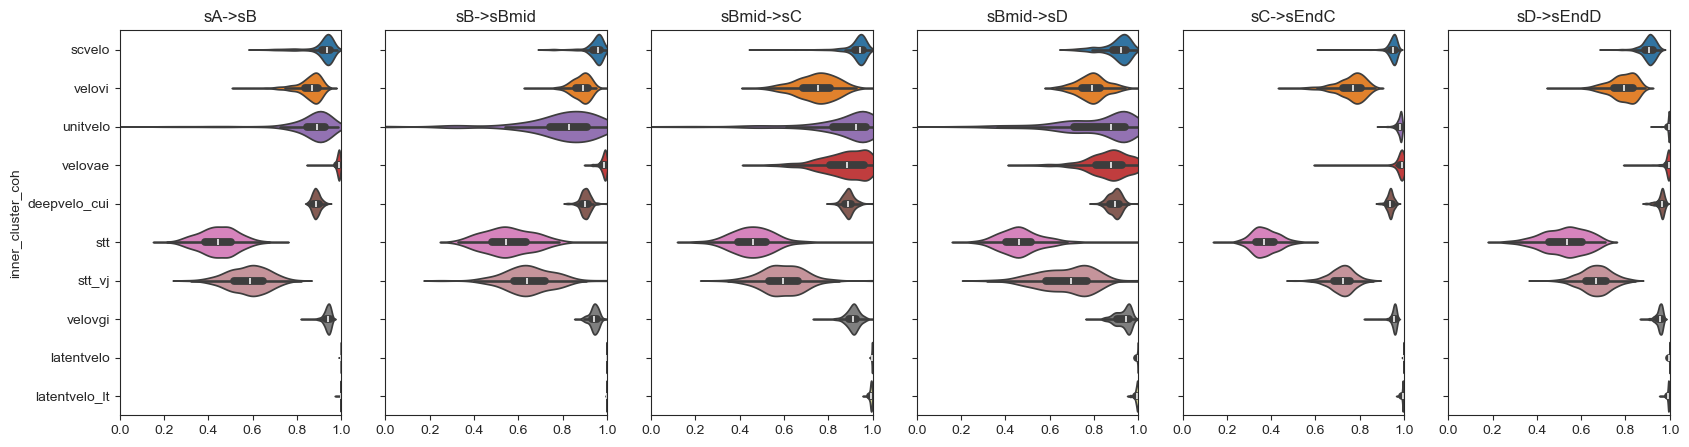

In [12]:
fig, axs = plt.subplots(1, len(results), figsize=(20, 5), sharex=True, sharey=True)
for i, (key, value) in enumerate(results.items()):
    df = pd.DataFrame([(k, v) for k, values in value.items() for v in values], columns=["model", metric_name])
    sns.violinplot(x=metric_name, y='model', data=df, palette=model_colors, ax=axs[i])
    axs[i].set_title(key)
    axs[i].set_xlim(0, 1)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(metric_name)
    # plt.ylim(0, 1) # remember to change this
    # plt.title(key)
    # plt.show()

/tmp/ipykernel_3154760/2479734518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)


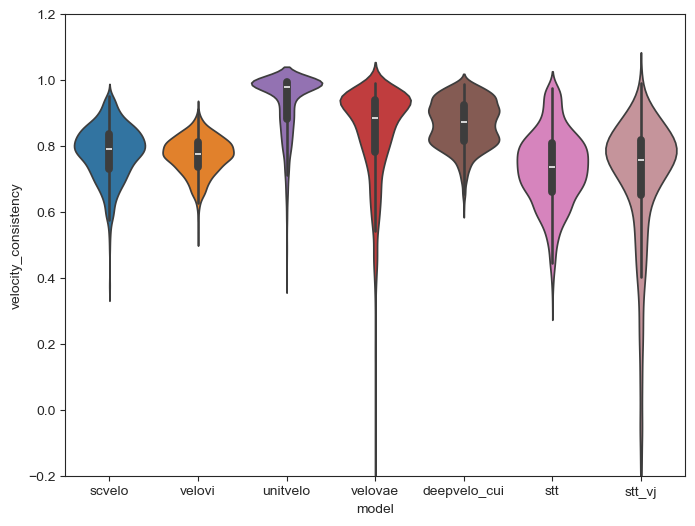

In [32]:
df = pd.DataFrame([(k, v) for k, values in result.items() for v in values], columns=["model", metric_name])
plt.figure(figsize=(8, 6))
sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)
plt.ylim(-0.2, 1.2)
plt.savefig(f'{save_dir}/{metric_name}.svg')
plt.show()